# Introduction
This notebook uses a Tanager orthorectified radiance/top of atmosphere image to assess the atmospheric composition surrounding the Monroe Canyon Fire. According to the morning update from Incident Management Team on the day the image was collected, the plan for the day was for firefighters to light strategic fires intended to deprive the main fire of fuel when it reached the same ground. Increased smoke activity was listed as a possible hazard from these activities.

This analysis aims to differentiate between wildfire smoke and other atmospheric materials within the image. Wildfire smoke will be identified by creating a customized normalized difference index targeting the specific bands with high CO2 absorption. Mapping smoke distribution will be critical for tracking public health impacts, emissions, and masking surface reflectance products.

In [1]:
import h5py
import rasterio
import requests
import sys
import numpy as np
import matplotlib.pyplot as plt
from numpy.lib.stride_tricks import sliding_window_view
from scipy.ndimage import binary_opening, binary_closing, generic_filter
from rasterio.transform import from_origin
from sklearn.decomposition import PCA
from pathlib import Path

# Import custom utility functions
wrkspc = Path.cwd().parent
if str(wrkspc) not in sys.path:
    sys.path.insert(0, str(wrkspc))

from utils import tanager_utils

# Data Preparation
This section will walk through downloading the Tanager scene directly from the public STAC endpoint, viewing its properties such as radiometric coefficients, and masking the cube using the out of the box cloud masks.

### Download Orthorectified Top of Atmosphere (TOA) Image

In [2]:
url = "https://storage.googleapis.com/open-cogs/planet-stac/tanager1-release2-core-imagery/ortho_radiance_hdf5/20250724_190927_83_4001_ortho_radiance_hdf5.h5"
toa_h5_path = Path(r"../data/images/ortho_toa_hdf5.h5")
toa_h5_path.parent.mkdir(parents=True, exist_ok=True)

if toa_h5_path.exists():
    print(f"TOA radiance image saved in '{toa_h5_path}'.")
else:
    with requests.get(url, stream=True) as r:
        r.raise_for_status()
        with open(toa_h5_path, "wb") as f:
            for chunk in r.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    f.write(chunk)
    print(f"Surface reflectance image downloaded to '{toa_h5_path}'.")

# Check out what is included in the download
with h5py.File(toa_h5_path) as img:
    print("File Structure:")
    img.visititems(tanager_utils.print_structure)


TOA radiance image saved in '..\data\images\ortho_toa_hdf5.h5'.
File Structure:
HDFEOS (Group)
  HDFEOS/ADDITIONAL (Group)
    HDFEOS/ADDITIONAL/FILE_ATTRIBUTES (Group)
  HDFEOS/GRIDS (Group)
    HDFEOS/GRIDS/HYP (Group)
      HDFEOS/GRIDS/HYP/Data Fields (Group)
        HDFEOS/GRIDS/HYP/Data Fields/beta_cirrus_mask (Dataset)
        HDFEOS/GRIDS/HYP/Data Fields/beta_cloud_mask (Dataset)
        HDFEOS/GRIDS/HYP/Data Fields/nodata_pixels (Dataset)
        HDFEOS/GRIDS/HYP/Data Fields/sensor_azimuth (Dataset)
        HDFEOS/GRIDS/HYP/Data Fields/sensor_to_ground_path_length (Dataset)
        HDFEOS/GRIDS/HYP/Data Fields/sensor_zenith (Dataset)
        HDFEOS/GRIDS/HYP/Data Fields/sun_azimuth (Dataset)
        HDFEOS/GRIDS/HYP/Data Fields/sun_zenith (Dataset)
        HDFEOS/GRIDS/HYP/Data Fields/time (Dataset)
        HDFEOS/GRIDS/HYP/Data Fields/toa_radiance (Dataset)
HDFEOS INFORMATION (Group)
  HDFEOS INFORMATION/StructMetadata.0 (Dataset)


In [3]:
with h5py.File(toa_h5_path, 'r') as f:
    # attrs on the radiance dataset itself
    ds = f['HDFEOS/GRIDS/HYP/Data Fields/toa_radiance']
    
    print("toa_radiance attrs:")
    for k, v in ds.attrs.items(): # get wavelength centers and fwhm values 
        print(" ", k, "->", v)
        print(k)
        if k == 'wavelengths':
            wavelengths = np.array(v)
        elif k == 'fwhm':
            fwhm = np.array(v)
    radiance = f['HDFEOS/GRIDS/HYP/Data Fields/toa_radiance'][:]
    cloud_mask = f['HDFEOS/GRIDS/HYP/Data Fields/beta_cloud_mask'][:]
    cirrus_mask = f['HDFEOS/GRIDS/HYP/Data Fields/beta_cirrus_mask'][:]
    nodata = f['HDFEOS/GRIDS/HYP/Data Fields/nodata_pixels'][:]

toa_radiance attrs:
  Unit -> W/(m^2 sr um)
Unit
  _FillValue -> -9999.0
_FillValue
  applied_radiometric_coefficients -> [0.24117877 0.19664247 0.12794702 0.10599381 0.0785861  0.06810818
 0.05935678 0.04755091 0.04190101 0.03722739 0.03394626 0.0303052
 0.02826379 0.02598685 0.02387025 0.02336355 0.02251674 0.02208806
 0.02204469 0.02220925 0.02168082 0.02049176 0.01993347 0.01987995
 0.01913034 0.01838925 0.01796245 0.01744622 0.01674083 0.01709536
 0.01676122 0.01611635 0.01537274 0.01469532 0.0143942  0.01404121
 0.01360779 0.01338364 0.01328742 0.01275896 0.01256888 0.01229605
 0.01184709 0.01151312 0.01140921 0.01112384 0.01085087 0.01073875
 0.01054627 0.01030221 0.0100322  0.01017956 0.01043109 0.01048737
 0.01056168 0.01062509 0.01038046 0.01180799 0.01294908 0.01158617
 0.01024127 0.01051945 0.01077913 0.01044896 0.00998824 0.00947738
 0.00940376 0.00939155 0.00935765 0.00926195 0.00920742 0.00921969
 0.00927409 0.00924037 0.00916314 0.0090442  0.00935355 0.00856564
 0.00894

In [4]:
good = ( # mask for no-data and clouds
    (nodata == 0) &
    (cloud_mask == 0) 
    # (cirrus_mask == 0)
)
radiance = np.moveaxis(radiance, 0, -1) # move axis so the shape is 702, 846, 426 

radiance.shape # print out shape to confirm

(702, 846, 426)

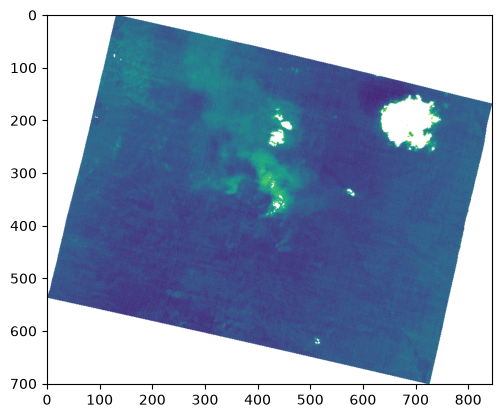

In [5]:
radiance[~good, :] = np.nan # apply nan's to the mask values 
plt.imshow(radiance[:,:,1])# show masked data to confirm

# Plume Detection and Modeling
This analysis is based upon the methodology developed in [Ning et al., 2025](https://doi.org/10.3390/agriculture15171835), where the authors created a mean background image to compare against a gas plume. The spectral signature of the target gas plume is significantly different than the generated background at certain wavelengths, and can be differentiated using a normalized index. 

Using Tanager's 426 bands allows this plume detection method to target much more specific gasses than multispectral sensors. In this case, we will target bands with high CO2 *absorption* for the calculated index. Pixels that have a very high index value are likely to contain much higher concentrations of CO2 than the rest of the image, indicating that they contain smoke or significant haze from the fire.

### Calculate background images

In [6]:
background  = radiance[:,:,0:3] # select background grids 
back = tanager_utils.generate_new_background(background) # generate 3 background bands 
back2 = tanager_utils.generate_new_background(background) # generate 3 background bands
back = np.dstack([background, back, back2]) # combine all the background bands so that there is 9 total background bands 

100%|██████████| 3/3 [00:00<00:00, 77.90it/s]


In [7]:
# Check shape and axis alignment
nb = radiance[:,:,:]
print(nb.shape)
print(back.shape)

(702, 846, 426)
(702, 846, 9)


In [8]:
diff = nb * 9 - back.sum(axis=-1, keepdims=True) # The difference here is each pixel nb[i,j,z] * 9 (To scale accordingly) - sum of the pixel values in the 9 bands of the background

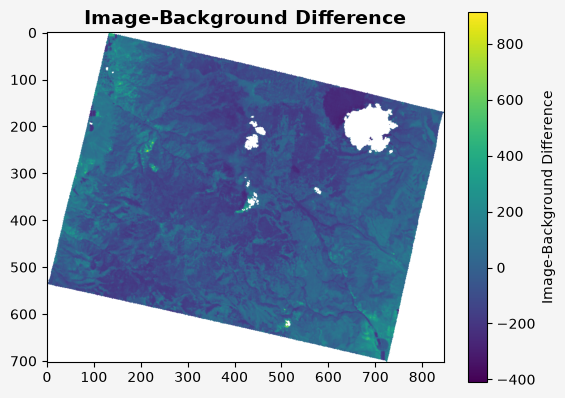

In [9]:
plt.imshow(diff[:,:, 50]) # show the difference raster at band 50 - this is just a test
plt.title("Image-Background Difference",
            fontsize=14,
          fontweight='bold')
plt.gcf().set_facecolor('whitesmoke')
plt.colorbar(label = 'Image-Background Difference')
plt.show()

Text(0, 0.5, 'Image-Background Difference')

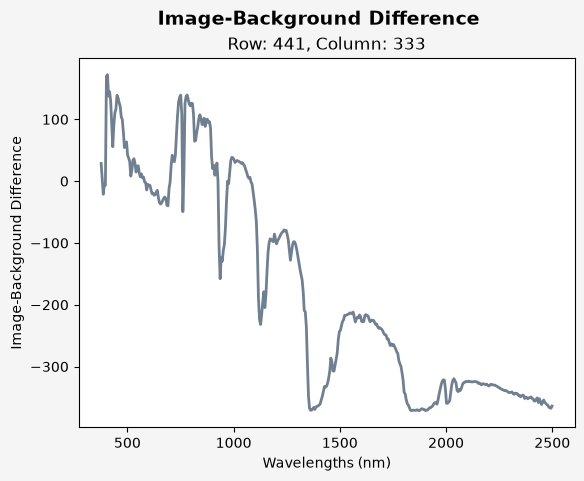

In [10]:
row = 441 # change row/column based on pixel of interest
column = 333
plt.style.use('petroff6')
plt.gcf().set_facecolor('whitesmoke')
plt.plot(wavelengths, diff[row,column,:], color = 'slategrey', lw='2') # plot the wavelengths for a single cell
plt.suptitle(f"Image-Background Difference",
          fontsize=14,
          fontweight='bold')
plt.title(f'Row: {str(row)}, Column: {str(column)}')
plt.xlabel("Wavelengths (nm)")
plt.ylabel('Image-Background Difference')

### Create normalized difference index for plume detection

In [11]:
band_min = np.nanmin(diff, axis=(0,1), keepdims = True) # get the minimum of diff 
band_max = np.nanmax(diff, axis=(0,1), keepdims=True) # get the maximum of diff
scaled = (band_max - diff) / (band_max - band_min) # normalize values so higher values mean higher likelihood of Co2

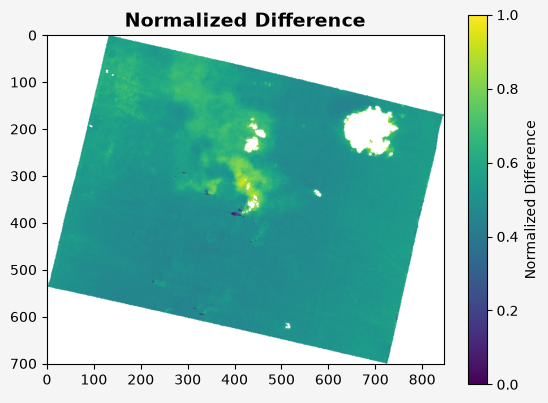

In [12]:
plt.imshow(scaled[:,:,370]) # show the scaled differences
plt.colorbar(label='Normalized Difference')
plt.title("Normalized Difference",
                    fontsize=14,
          fontweight='bold')
plt.gcf().set_facecolor('whitesmoke')

In [13]:
co2_band = np.where( # wavelengths where we would expect to see Co2 absorption
    (wavelengths > 2000) &
    (wavelengths < 2300)
)[0]

### Extract plume

In [14]:
co2_scaled = scaled[:,:,co2_band] # pull out only the scaled values from the co2 bands
mn = np.nanmean(co2_scaled, axis = -1) # get the mean values of the scaled co2 bands
plume = mn > 0.6 # create a boolean array which is True where values are greater than 0.6

C:\Users\jtaylor\AppData\Local\Temp\ipykernel_20456\3087160114.py:2: RuntimeWarning: Mean of empty slice
  mn = np.nanmean(co2_scaled, axis = -1) # get the mean values of the scaled co2 bands


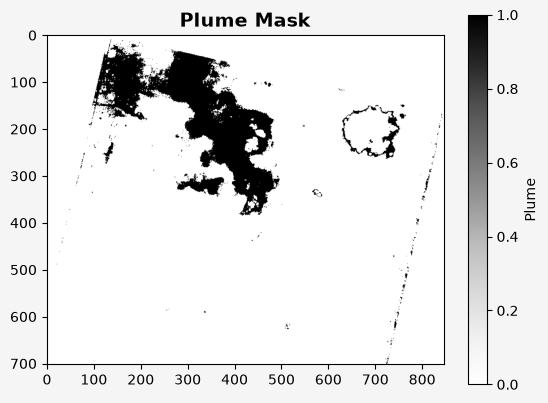

In [15]:
plt.imshow(plume, cmap="Greys") # show the plume mask 
plt.colorbar(label = 'Plume')
plt.title('Plume Mask',
          fontsize=14,
          fontweight='bold')
plt.gcf().set_facecolor('whitesmoke')

### Export Plume Mask Results

The results of this analysis will be exported as both a GeoTiff and NumPy array. The GeoTiff can be imported into a GIS for further visualization and analysis. The NumPy array will be used in Notebook 2: Burn Severity Analysis.

In [16]:
# Save array to data folder
plume_npy_path = Path(r"../data/plume_mask.npy")
np.save(plume_npy_path, plume)
print(f"Plume mask array saved to '{plume_npy_path}'")

# Save GeoTiff to images folder
plume_tif_path = Path(r"../data/images/plume_mask.tif")
with h5py.File(toa_h5_path) as img:
    geoinfo = tanager_utils.georeference_h5(img)
with rasterio.open(
    plume_tif_path,
    "w",
    height=geoinfo["shape"][0],
    width=geoinfo["shape"][1],
    count=1,
    dtype="uint8",
    crs=geoinfo["crs"],
    transform=geoinfo["transform"],
) as file:
    file.write(plume.astype("uint8"), 1)
print(f"PLume mask tif saved to '{plume_tif_path}'")

Plume mask array saved to '..\data\plume_mask.npy'
PLume mask tif saved to '..\data\images\plume_mask.tif'


# Conclusions
This notebook demonstrated how to download and extract spectral and radiometric information from an orthorectified Tanager TOA image. After preparing the dataset, out of the box cloud masks were used to remove pixels without useful information. 

The main analysis used a recently developed gas plume identification method to extract the main portion of the fire's smoke plume using a normalized difference index specifically targeting the spectral signature of CO2. This index was possible due to Tanager's very high spectral and radiometric resolution.

The product created by this analysis will be used in Notebook 2. Additional use cases for these data could include tracking the smoke plume for public health impacts, informing fire behavior analyses, and quantifying emissions of specific gasses.